In [1]:
from platform import python_version
print(python_version())

3.11.14


In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

sys.path.insert(0, ROOT_SRC)


if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import create_dir
from libs.MTD_lib import MTD
from libs.cBioPortal_lib import cBioPortal
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config
from libs.prism_lib import PRISM
from libs.prism_program_lib import *


from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages
  warnings.warn(
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'BRCA'
PSI_ID = 'ACC'
PSI_ID = 'CESC'
PSI_ID = 'PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/PAAD/config/all_lfc_cutoffs_PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", mtd.disease, case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=True, verbose=False)
print("\nEcho Parameters:")
print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/PAAD
>>> PAAD Tumor
>>> case Tumor
>>> psi_id or disease: PAAD
Error: No data available for the specified PAAD.
Error: could not find /home/flavio/uv/perturb_agent/data/TCGA/PAAD/lfc/PAAD_final_LFC_Tumor_x_CTRL_not_normalized.tsv
No dflfc table was calculated for this case Tumor

Echo Parameters:
	0/0 DEGs/ensembl.
		Up 0/0 DEGs/ensembl.
		Dw 0/0 DEGs/ensembl.

Found 0 (best=3) pathways for geneset num=0 'Reactome_Pathways_2024'
Pathway cutoffs p-value=0.050 fdr=0.050 min genes=0.05No enrichment analysis was calculated.


In [5]:
cbio = cBioPortal(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

### Get all programs

In [6]:
verbose = False

df_psi = cbio.open_primary_site(verbose=verbose)
df_psi

,prog_id,cbioportal_study_id,active,gdc_project_id,psi_id,disease_id,disease_cd,primary_site,disease_context
0,TCGA,paad_tcga_pan_can_atlas_2018,True,TCGA-PAAD,PAAD,pancreatic_adenocarcinoma,PAAD,Pancreas,"TCGA pancreatic adenocarcinoma, PanCancer Atlas"
1,CPTAC3,paad_cptac_2021,True,CPTAC-3,PAAD,pancreatic_ductal_adenocarcinoma,PAAD,Pancreas,"CPTAC publication cohort, Cell 2021; 140 pancreatic cancers"
2,TCGA,skcm_tcga_pan_can_atlas_2018,True,TCGA-SKCM,SKCM,cutaneous_melanoma,SKCM,Skin,"TCGA skin cutaneous melanoma, PanCancer Atlas"
3,TCGA,brca_tcga_pan_can_atlas_2018,True,TCGA-BRCA,BRCA,breast_invasive_carcinoma,BRCA,Breast,"TCGA breast invasive carcinoma, PanCancer Atlas"
4,CPTAC2,brca_cptac_2020,True,CPTAC-2,BRCA,breast_cancer,BRCA,Breast,"CPTAC breast cancer publication cohort, Cell 2020"


### Open primary cites from cbio

In [7]:
PROG_ID = 'TCGA'
psi_id = 'PAAD'
psi_id = 'SKCM'
psi_id = 'BRCA'

PROG_ID = 'CPTAC2'
psi_id = 'BRCA'

PROG_ID = 'CPTAC3'
psi_id = 'PAAD'

### Prism - development

In [8]:
import anndata as ad

prism = PRISM(root0=ROOT0, root0_data=ROOT0_DATA)

verbose=True

prism.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, verbose=verbose)

prism.root_prism, prism.root_prism.exists()

Table opened ((7, 9)) at '/home/flavio/uv/perturb_agent/data/cbioportal_study_mapping.tsv'

-----------------------------
>> prog_id: CPTAC3
>> psi_id: PAAD
>> primary_site: Pancreas
>> disease_id: pancreatic_ductal_adenocarcinoma
>> disease_cd: PAAD

-----------------------------
>> cbioportal_study_id: paad_cptac_2021
>> gdc_project_id: CPTAC-3

-----------------------------
>> root disease: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD
>> root samples: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/samples
>> root lfc: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/lfc
>> root mutations: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/mutations
-----------------------------



(PosixPath('/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism'), True)

### Running prism

In [9]:
verbose=True

res = prism.open_bayesprism(verbose=verbose)
print(len(res.genes))

Loaded /home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/deconv.h5ad (8.1 MB)
1918


In [10]:
res.states

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

In [11]:
res.theta_type.columns

Index(['Acinar cell', 'B cell', 'Ductal cell type 1', 'Endocrine cell', 'Endothelial cell',
       'Fibroblast cell', 'Macrophage cell', 'Stellate cell', 'T cell', 'malignant'],
      dtype='object')

In [12]:
print(res.theta.shape)
res.theta.head(5)

(153, 10)


,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
T-C3L-02890,0.603,8.666e-03,0.025,0.029,8.828e-73,0.018,0.105,1.176e-152,1.083e-01,0.104
T-C3L-03635,0.760,5.456e-03,0.016,0.028,2.978e-163,0.008,0.183,4.146e-105,2.173e-72,0.000
T-C3L-02701,0.763,1.275e-08,0.027,0.015,1.957e-222,0.005,0.175,1.414e-02,1.685e-148,0.000
T-C3L-04072,0.296,1.671e-02,0.076,0.034,1.428e-144,0.036,0.514,0.000e+00,2.690e-02,0.001
T-C3L-00589,0.384,4.344e-02,0.048,0.036,2.727e-125,0.014,0.422,1.177e-296,1.481e-02,0.038


In [13]:
res.theta.tail(5)

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
N-C3L-02606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N-C3N-03173,0.003,0.040,0.002,0.007,2.048e-85,4.374e-03,0.929,0.000,0.013,3.553e-114
N-C3N-02696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N-TCGA-H6-8124,0.581,0.014,0.089,0.030,4.796e-138,4.272e-16,0.094,0.004,0.153,3.388e-02
N-TCGA-H6-A45N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Ductal cell type 1

"Ductal cell type 1" is the normal-like ductal population and stays in the environment compartment — which is what you want. If both had been mapped to malignant, purity would inflate. Verify with res.tumor_purity.groupby(meta["condition"]).describe(): normals near zero, tumors somewhere in 0.2–0.6.


### Ductal cell type 2

One malignant state means no Ductal cell type 2 subdivision, so subtype_malignant scores Moffitt signatures on a single pooled malignant profile. That still works — it's per-sample expression, so samples can differ — but it won't give you distinct malignant states in θ. For that you'd subcluster Ductal cell type 2 in the AnnData and write finer cell_state labels before calling pseudobulk_reference.

In [14]:
res.cell_type_expression("Ductal cell type 1").shape

(1918, 153)

In [15]:
res.cell_type_expression("Ductal cell type 1").head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
ENSG00000000938,51.301,NaN,NaN,37.533,71.738,133.775,NaN,103.585,65.544,NaN,...,NaN,42.916,38.229,NaN,NaN,NaN,39.535,NaN,81.539,NaN
ENSG00000001617,46.895,NaN,NaN,139.224,37.504,111.861,NaN,48.340,100.671,NaN,...,NaN,56.004,34.789,NaN,NaN,NaN,33.189,NaN,84.933,NaN
ENSG00000001626,98976.750,NaN,NaN,60517.504,64058.141,12317.005,NaN,85658.117,93382.445,NaN,...,NaN,44093.203,37337.992,NaN,NaN,NaN,32737.848,NaN,77932.102,NaN


In [16]:
res.cell_type_expression("Ductal cell type 2").shape

(1918, 153)

In [17]:
res.cell_type_expression("Ductal cell type 2").head(3)

,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
ENSG00000000938,105.698,49.471,169.428,75.978,130.365,249.999,127.351,187.454,110.75,131.444,...,NaN,60.164,65.509,NaN,NaN,NaN,95.958,NaN,204.643,NaN
ENSG00000001617,211.804,188.735,283.416,617.821,149.403,458.264,447.011,191.767,372.90,247.584,...,NaN,172.114,130.685,NaN,NaN,NaN,176.593,NaN,467.284,NaN
ENSG00000001626,4642.306,1529.108,865.661,2788.810,2650.019,523.997,1481.312,3528.819,3592.04,1061.946,...,NaN,1407.204,1456.537,NaN,NaN,NaN,1808.896,NaN,4452.575,NaN


### 2. theta is now fixed -> expand Z to every gene

In [18]:
verbose=False
force=False

imax_tumor=250
imax_normal=50

exclude_prog_list=['CCLE']
disease_cd = 'PAAD'

dfn_tumor, dfn_normal, df_gtex, df_summ = cbio.get_all_data_from_disease(disease_cd=disease_cd, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list,
                                                           force=force, verbose=verbose)

verbose=True
force=False

df_bulk, df_meta = prism.build_bulk_matrix(dfn_tumor, dfn_normal, cbio.df_metadata, 
                                        keep_biotypes=("protein_coding", "lncRNA", "miRNA"),
                                        force=force, verbose=verbose)

force=False
verbose=True
fname = "count-matrix.txt"
fname_ad = fname.replace('.txt', '.h5ad')

adata = prism.load_matrix(fname=fname, sep=' ', force=force, verbose=verbose)

filename_ad = prism.root_prism / fname_ad
compression = "gzip"

verbose=True
fname_celltype = "all_celltype.txt"
adata = prism.attach_celltypes(adata=adata, fname_celltype=fname_celltype, verbose=verbose)

ref, s2t = prism.pseudobulk_reference(adata)

Error reading csv/tsv '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_gtex_controls_counts.tsv': No columns to parse from file
Table opened ((27177, 153)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/bulk_matrix_geneid.tsv'
Table opened ((153, 4)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/bulk_metadata_geneid.tsv'
57,530 cells x 24,005 genes | obs: []
all_celltype.txt columns: ['cluster']
                             cluster
cell.name                           
T1_AAACCTGAGATGTCGG  Fibroblast cell
T1_AAACGGGGTCATGCAT    Stellate cell
T1_AAAGATGCATGTTGAC  Macrophage cell
using type_col='cluster'
barcode overlap: 57,530 / 57,530
cell_type
malignant             11315
Ductal cell type 1    10317
Endothelial cell       9117
Fibroblast cell        6742
Stellate cell          5907
Macrophage cell        5361
T cell                 3660
B cell                 2447
Acinar cell            1935
Endocrine cell          729
Name: count, dtype

### Bulk - by geneid

In [19]:
force=False
verbose=True

df_bulk, df_meta = prism.build_bulk_matrix(dfn_tumor, dfn_normal, cbio.df_metadata, 
                                        keep_biotypes=("protein_coding", "lncRNA", "miRNA"),
                                        gene_key="geneid", force=force, verbose=verbose)

#--- reference geneid --> 
gene_map = prism.load_gene_map("geneid")
print(df_bulk.shape)
df_bulk.head(2)

Table opened ((27177, 153)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/bulk_matrix_geneid.tsv'
Table opened ((153, 4)) at '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/prism/bulk_metadata_geneid.tsv'
(27177, 153)


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,891,1063,1261,1821,554,1244,977,1576,3738,369
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,0,7,2,6,1,1,3,39,4,5


In [20]:
bulk_symbs = pd.read_csv(prism.root_prism / "bulk_matrix.tsv", sep="\t", index_col=0, usecols=[0])

### ref_new --> new reference, by geneid (ensbeml)

In [21]:
force=False
verbose=False

ref_new, df_to_from = prism.harmonize_reference_to_ensembl(bulk_symbs=bulk_symbs, ref=ref, gene_map=gene_map, force=False, verbose=verbose)

print(ref_new.shape)
print(df_to_from.status.value_counts())
ref_new.head(2)

(10, 17540)
status
ok               17540
no_ensembl_id     6249
Name: count, dtype: int64


,ENSG00000225880,ENSG00000187634,ENSG00000188976,ENSG00000187961,ENSG00000187583,ENSG00000188290,ENSG00000187608,ENSG00000188157,ENSG00000237330,ENSG00000131591,...,ENSG00000167355,ENSG00000184999,ENSG00000235910,ENSG00000157335,ENSG00000257008,ENSG00000166573,ENSG00000268182,ENSG00000254453,ENSG00000226245,ENSG00000213424
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,214.0,1246.0,2337.0,115.0,90.0,4981.0,18665.0,1758.0,11.0,274.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,162.0,112.0,1719.0,52.0,26.0,9730.0,16767.0,1611.0,2.0,172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### ref_new, s2t

In [22]:
print(ref_new.shape)
ref_new.head(3)

(10, 17540)


,ENSG00000225880,ENSG00000187634,ENSG00000188976,ENSG00000187961,ENSG00000187583,ENSG00000188290,ENSG00000187608,ENSG00000188157,ENSG00000237330,ENSG00000131591,...,ENSG00000167355,ENSG00000184999,ENSG00000235910,ENSG00000157335,ENSG00000257008,ENSG00000166573,ENSG00000268182,ENSG00000254453,ENSG00000226245,ENSG00000213424
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,214.0,1246.0,2337.0,115.0,90.0,4981.0,18665.0,1758.0,11.0,274.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,162.0,112.0,1719.0,52.0,26.0,9730.0,16767.0,1611.0,2.0,172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Macrophage cell,182.0,35.0,1293.0,66.0,47.0,918.0,19924.0,825.0,9.0,157.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
print(type(s2t), len(s2t))
s2t

<class 'pandas.core.series.Series'> 10


cell_state
Fibroblast cell          Fibroblast cell
Stellate cell              Stellate cell
Macrophage cell          Macrophage cell
Endothelial cell        Endothelial cell
T cell                            T cell
B cell                            B cell
Ductal cell type 2             malignant
Endocrine cell            Endocrine cell
Ductal cell type 1    Ductal cell type 1
Acinar cell                  Acinar cell
Name: cell_type, dtype: object

### why Zfull resulted in 16550 genes?

Because full_Z reconstructs the full gene set, not the subset BayesPrism fitted on.

The three numbers you've seen trace it:

- 16550 — genes in full_Z, the whole expression matrix
- 1604 — genes in cell_type_expression, the marker-based fit
- ~10000 — after min_share/min_counts filtering

BayesPrism runs on gene_subset (marker/signature genes) for tractability and identifiability. That gave 1604. 

full_Z then projects the remaining ~15000 genes onto the fitted compartment basis — which is precisely why you built it: to recover the lncRNA/antisense loci (FAM83A-AS1, HOXA10-AS, HOXB-AS3/4, MIR7-3HG) that the marker fit excluded.

Shape is (153 samples, 10 cell types, 16550 genes) — build_ms_from_full_Z resolves that axis order automatically.

The consequence you should hold onto: 
- those ~15000 recovered genes are not Gibbs posterior estimates. 
- they're projections onto a basis fitted from 1604 genes, 
- so their sampling variance is structurally different 
  - no posterior shrinkage in the same sense, 
  - and their between-sample variation partly reflects the projection rather than compartment-specific evidence.

In [24]:
Zfull, genes_full = prism.full_Z(res, df_bulk, ref_new)
print(Zfull.shape)

Zfull[0][3][:5]

(153, 10, 17540)


array([54.085945,  6.94367 , 42.73008 , 46.775616, 13.698739],
      dtype=float32)

In [25]:
dic = {}

for cell_state in res.states:
    Z = prism.state_expression(Zfull, genes_full, res, cell_state)
    dic[cell_state] = Z
    print(cell_state, Z.shape)


Fibroblast cell (17540, 153)
Stellate cell (17540, 153)
Macrophage cell (17540, 153)
Endothelial cell (17540, 153)
T cell (17540, 153)
B cell (17540, 153)
Ductal cell type 2 (17540, 153)
Endocrine cell (17540, 153)
Ductal cell type 1 (17540, 153)
Acinar cell (17540, 153)


In [26]:
i=0
key = list(dic.keys())[i]

print(key)
dic[key]

Fibroblast cell


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
ENSG00000000003,3.207e+01,5.801e+01,4.361e+01,32.366,3.406e+01,31.881,3.565e+01,5.433e+01,30.481,40.203,...,NaN,16.647,16.364,NaN,NaN,NaN,27.003,NaN,53.037,NaN
ENSG00000000005,1.556e-01,1.310e+00,2.711e-01,0.029,1.720e-01,0.058,1.358e-01,8.509e-02,0.060,0.182,...,NaN,0.124,0.020,NaN,NaN,NaN,0.119,NaN,0.035,NaN
ENSG00000000419,4.123e+01,4.310e+01,4.238e+01,62.828,4.240e+01,43.955,2.572e+01,4.332e+01,42.273,46.569,...,NaN,25.995,36.263,NaN,NaN,NaN,21.046,NaN,32.622,NaN
ENSG00000000457,3.290e+01,5.382e+01,2.546e+01,31.656,3.979e+01,32.726,2.998e+01,3.380e+01,31.080,40.644,...,NaN,16.563,21.391,NaN,NaN,NaN,17.661,NaN,15.153,NaN
ENSG00000000460,1.502e+01,2.333e+01,8.703e+00,16.155,1.337e+01,12.151,8.187e+00,9.839e+00,12.122,12.879,...,NaN,7.853,9.335,NaN,NaN,NaN,6.459,NaN,4.055,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000287971,2.388e-09,6.709e-10,6.899e-10,0.000,9.010e-10,0.000,8.077e-10,3.939e-09,0.000,0.000,...,NaN,0.000,0.000,NaN,NaN,NaN,0.000,NaN,0.000,NaN
ENSG00000288302,8.825e-02,7.354e-02,1.746e-01,0.000,4.293e-01,0.094,0.000e+00,7.508e-02,0.054,0.516,...,NaN,0.000,0.364,NaN,NaN,NaN,5.905,NaN,0.191,NaN
ENSG00000288547,6.591e-01,3.459e-01,3.643e-01,0.615,4.794e-01,0.212,4.817e-01,3.034e-01,0.131,0.509,...,NaN,0.914,0.099,NaN,NaN,NaN,0.724,NaN,4.869,NaN
ENSG00000288596,1.110e+01,1.045e+01,5.792e+00,9.570,1.071e+01,8.293,8.219e+00,8.764e+00,8.785,8.110,...,NaN,9.559,5.357,NaN,NaN,NaN,6.290,NaN,2.457,NaN


### Ductal 2 - malignant

In [27]:
Zmal = prism.state_expression(Zfull, genes_full, res, "Ductal cell type 2")

In [28]:
for g in ["FAM83A-AS1", "HOXA10-AS", "HOXB-AS3", "MIR7-3HG"]:
    if g in genes_full:
        print(g, prism.gene_compartment_share(Zfull, genes_full, res, g).head(3).round(3).to_dict())

In [29]:
prog1 = ["FAM83A-AS1", "HOXA10-AS", "HOXB-AS3", "HOXB-AS4", "MIR7-3HG"]

prog2 = ["GATA6", "KRT17", "NEAT1", "H19", "DLEU1", "DLEU2"]

### survived build_bulk_matrix?

> Almost certainly df_bulk is the culprit: build_bulk_matrix defaults to keep_biotypes=("protein_coding",), which removes every lncRNA. Rebuild with them included:

In [30]:
[g for g in prog1 if g in df_bulk.index]

[]

### present in the scRNA reference?

In [31]:
  
[g for g in prog1 if g in ref_new.columns]

[]

### Data treatment

1. get raw dfc
2. filter low-expression genes
3. normalize for library size
4. variance-stabilizing transformation
5. select most variable genes
6. cluster samples into k = 3..8 groups
7. evaluate clusters
8. find gene signatures for each cluster

A low-expression gene can be biologically important and even differentially expressed, especially if it is a transcription factor, cytokine, receptor, lncRNA, or rare-cell marker.

But for unsupervised tumor clustering, we usually do not want thousands of genes with mostly zero/very low counts because they add noise and unstable distances.

In [32]:
set(ref.index.to_list())

{'Acinar cell',
 'B cell',
 'Ductal cell type 1',
 'Ductal cell type 2',
 'Endocrine cell',
 'Endothelial cell',
 'Fibroblast cell',
 'Macrophage cell',
 'Stellate cell',
 'T cell'}

In [33]:
set(s2t.index.to_list())

{'Acinar cell',
 'B cell',
 'Ductal cell type 1',
 'Ductal cell type 2',
 'Endocrine cell',
 'Endothelial cell',
 'Fibroblast cell',
 'Macrophage cell',
 'Stellate cell',
 'T cell'}

In [34]:
adata.obs

,cluster,cell_type,cell_state
cell,,,
T1_AAACCTGAGATGTCGG,Fibroblast cell,Fibroblast cell,Fibroblast cell
T1_AAACGGGGTCATGCAT,Stellate cell,Stellate cell,Stellate cell
T1_AAAGATGCATGTTGAC,Macrophage cell,Macrophage cell,Macrophage cell
T1_AAAGATGGTCGAGTTT,Macrophage cell,Macrophage cell,Macrophage cell
T1_AAAGATGGTCTCTCTG,Endothelial cell,Endothelial cell,Endothelial cell
...,...,...,...
N11_TTTGCGCGTGCGCTTG,Endothelial cell,Endothelial cell,Endothelial cell
N11_TTTGGTTCATTGAGCT,Acinar cell,Acinar cell,Acinar cell
N11_TTTGGTTGTCCGACGT,Ductal cell type 1,Ductal cell type 1,Ductal cell type 1


In [35]:
import re, numpy as np, pandas as pd

adata.obs["sample"] = adata.obs_names.to_series().str.extract(r"^([TN]\d+)_")[0].values
adata.obs["tissue"] = np.where(adata.obs["sample"].str.startswith("T"), "tumor", "normal")

print(adata.obs.groupby("tissue")["sample"].nunique())      # expect tumor 24, normal 11
print(pd.crosstab(adata.obs["cell_state"], adata.obs["tissue"]))

tissue
normal    11
tumor     24
Name: sample, dtype: int64
tissue              normal  tumor
cell_state                       
Acinar cell           1423    512
B cell                  31   2416
Ductal cell type 1    7671   2646
Ductal cell type 2       0  11315
Endocrine cell         270    459
Endothelial cell      3983   5134
Fibroblast cell        940   5802
Macrophage cell        559   4802
Stellate cell          623   5284
T cell                  44   3616


### Count Malignant Cells - accordingo to transcriptomics

In [36]:
d2 = adata.obs["cell_state"].eq("Ductal cell type 2")
print(len(d2))
d2[:5]

57530


cell
T1_AAACCTGAGATGTCGG    False
T1_AAACGGGGTCATGCAT    False
T1_AAAGATGCATGTTGAC    False
T1_AAAGATGGTCGAGTTT    False
T1_AAAGATGGTCTCTCTG    False
Name: cell_state, dtype: bool

In [37]:
is_t = adata.obs["tissue"].eq("tumor")
print(np.sum(is_t))

41986


In [38]:
adata.obs["cell_state"] = np.where(d2 &  is_t, "Malignant ductal",
                          np.where(d2 & ~is_t, "Ductal cell type 2 normal",
                                   adata.obs["cell_state"]))
adata.obs

,cluster,cell_type,cell_state,sample,tissue
cell,,,,,
T1_AAACCTGAGATGTCGG,Fibroblast cell,Fibroblast cell,Fibroblast cell,T1,tumor
T1_AAACGGGGTCATGCAT,Stellate cell,Stellate cell,Stellate cell,T1,tumor
T1_AAAGATGCATGTTGAC,Macrophage cell,Macrophage cell,Macrophage cell,T1,tumor
T1_AAAGATGGTCGAGTTT,Macrophage cell,Macrophage cell,Macrophage cell,T1,tumor
T1_AAAGATGGTCTCTCTG,Endothelial cell,Endothelial cell,Endothelial cell,T1,tumor
...,...,...,...,...,...
N11_TTTGCGCGTGCGCTTG,Endothelial cell,Endothelial cell,Endothelial cell,N11,normal
N11_TTTGGTTCATTGAGCT,Acinar cell,Acinar cell,Acinar cell,N11,normal
N11_TTTGGTTGTCCGACGT,Ductal cell type 1,Ductal cell type 1,Ductal cell type 1,N11,normal


In [39]:
from collections import Counter

Counter(adata.obs["cell_state"] )

Counter({'Malignant ductal': 11315,
         'Ductal cell type 1': 10317,
         'Endothelial cell': 9117,
         'Fibroblast cell': 6742,
         'Stellate cell': 5907,
         'Macrophage cell': 5361,
         'T cell': 3660,
         'B cell': 2447,
         'Acinar cell': 1935,
         'Endocrine cell': 729})

In [40]:
adata.obs["cell_type"]  = np.where(adata.obs["cell_state"].eq("Malignant ductal"),
                                   "malignant", adata.obs["cell_type"])

Counter(adata.obs["cell_type"] )

Counter({'malignant': 11315,
         'Ductal cell type 1': 10317,
         'Endothelial cell': 9117,
         'Fibroblast cell': 6742,
         'Stellate cell': 5907,
         'Macrophage cell': 5361,
         'T cell': 3660,
         'B cell': 2447,
         'Acinar cell': 1935,
         'Endocrine cell': 729})

In [41]:
ref2, s2t = prism.pseudobulk_reference(adata, state_key="cell_state", type_key="cell_type")
s2t.to_dict()

{'Fibroblast cell': 'Fibroblast cell',
 'Stellate cell': 'Stellate cell',
 'Macrophage cell': 'Macrophage cell',
 'Endothelial cell': 'Endothelial cell',
 'T cell': 'T cell',
 'B cell': 'B cell',
 'Malignant ductal': 'malignant',
 'Endocrine cell': 'Endocrine cell',
 'Ductal cell type 1': 'Ductal cell type 1',
 'Acinar cell': 'Acinar cell'}

### LFC

calc_celltype_lfc() — each compartment vs the mean of the others, paired across samples by default. Paired is the right default here because every sample contributes every cell type, so pairing removes cohort/purity variance. This doubles as deconvolution QC: if the ductal compartment doesn't recover KRT19/TFF1/CEACAM6 and fibroblast doesn't recover COL1A1/POSTN, θ or the Peng reference is off and step 2 is meaningless.

### Critics

- Why not, for each cell type, tumor samples x normal samples
- Only Ductal 2 Tumor has no normal samples - to confirm


In [42]:
res.__dict__.keys()

dict_keys(['theta', 'theta_stage1', 'theta_type', 'tumor_purity', 'genes', 'Z', 'states'])

In [43]:
res.states

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

### MalignantCluster

In [44]:
cbio.root_mprog_disease

PosixPath('/home/flavio/uv/perturb_agent/data/multi_progs/PAAD')

In [45]:
import importlib, libs.prism_malig_lib as pml
importlib.reload(pml)
print(pml.__version__)

0.35.0


In [46]:
root_mprog_disease = cbio.root_mprog_disease
mal_cell_name = "Ductal cell type 2"


mc = pml.MalignantCluster(prism=prism, res=res, 
                          df_bulk=df_bulk, ref=ref_new, 
                          root_mprog_disease = root_mprog_disease,
                          mal_cell_name = mal_cell_name,
                          organ="Pancreas")

mc

### Turn compartment counts into a matrix it is safe to cluster.

In [47]:
X, diag = mc.prepare_malignant_matrix(decouple_purity=False, keep_genes=mc.program1_panel, drop_pattern=r"^N-")
print(X.shape)
X.head(3)

excluded 22/153 samples by keep_samples/drop_pattern
(118, 2000)


,ENSG00000001084,ENSG00000001561,ENSG00000002587,ENSG00000002726,ENSG00000002834,ENSG00000003147,ENSG00000003249,ENSG00000003400,ENSG00000004478,ENSG00000005001,...,ENSG00000274211,ENSG00000275342,ENSG00000275395,ENSG00000275410,ENSG00000276180,ENSG00000277363,ENSG00000277972,ENSG00000278259,ENSG00000278535,ENSG00000278540
T-C3L-02890,6.780,5.736,7.171,5.541,8.460,7.229,3.217,7.004,6.726,7.630,...,6.132,6.505,8.483,5.027,4.268,2.718,4.797,7.108,3.834,7.867
T-C3L-03635,6.269,5.560,7.215,6.130,8.503,8.109,4.257,6.930,7.244,7.363,...,6.472,5.909,6.709,6.371,3.522,3.931,4.802,7.070,4.182,8.450
T-C3L-02701,5.989,7.098,7.601,7.242,8.451,7.274,4.592,7.107,7.048,6.365,...,6.274,5.258,7.830,4.836,4.575,3.923,5.229,7.101,4.260,7.952


In [48]:
X.tail(3)

,ENSG00000001084,ENSG00000001561,ENSG00000002587,ENSG00000002726,ENSG00000002834,ENSG00000003147,ENSG00000003249,ENSG00000003400,ENSG00000004478,ENSG00000005001,...,ENSG00000274211,ENSG00000275342,ENSG00000275395,ENSG00000275410,ENSG00000276180,ENSG00000277363,ENSG00000277972,ENSG00000278259,ENSG00000278535,ENSG00000278540
T-TCGA-3A-A9IV,7.565,6.023,3.324,1.448,8.007,7.386,2.533,2.697,6.865,0.420,...,7.164,3.547,6.159,0.722,2.338,6.233,6.055,6.180,5.108,7.149
T-TCGA-2J-AABT,6.735,5.751,5.384,9.160,8.409,7.006,5.090,6.294,6.789,7.343,...,5.424,6.412,6.549,6.501,2.859,4.072,6.318,5.870,5.375,7.263
T-TCGA-H6-A45N,5.685,5.722,7.437,7.615,8.812,6.507,5.103,6.228,6.752,7.519,...,5.128,6.746,7.716,6.657,3.044,4.665,6.183,5.564,4.241,6.559


In [49]:
lista = [x for x in X.index if x.startswith('T-')]
X.shape[0], len(lista) == X.shape[0]

(118, True)

In [50]:
diag.keys()

dict_keys(['samples_excluded_by_filter', 'samples_dropped', 'n_genes_expressed', 'n_genes_share_not_computable', 'n_genes_share_ok', 'forced_genes_status', 'n_genes_kept', 'n_hvg', 'pc_theta_pearson_raw', 'pc_theta_pearson', 'decouple_purity', 'pc_theta_note', 'sample_mean_expr', 'sample_total_Z', 'theta_mal', 'n_samples_used', 'theta_excluded', 'theta_kept'])

In [51]:
diag["samples_excluded_by_filter"]

['N-C3L-04072',
 'N-C3L-00589',
 'N-C3L-03123',
 'N-C3L-04080',
 'N-C3L-00640',
 'N-C3N-01719',
 'N-C3L-07033',
 'N-C3L-00819',
 'N-C3L-07032',
 'N-C3L-01689',
 'N-C3N-01899',
 'N-C3N-00517',
 'N-C3N-03069',
 'N-C3N-02765',
 'N-C3L-07037',
 'N-C3N-02589',
 'N-C3N-02996',
 'N-C3L-02606',
 'N-C3N-03173',
 'N-C3N-02696',
 'N-TCGA-H6-8124',
 'N-TCGA-H6-A45N']

### pc_theta_pearson and pc_theta_pearson_raw

**The computation.** Run PCA on the samples × genes matrix, take the first 5 principal components, and correlate each PC's sample scores with `theta_mal` (each sample's malignant fraction). `pcs[:, i]` is one number per sample for PC *i*; `theta_mal.values` is one number per sample. `np.corrcoef(...)[0,1]` pulls the off-diagonal — the Pearson r between them.

You get 5 numbers, one per PC. Each answers: *does this dominant axis of variation track tumour purity?*

**The two versions:**

| | matrix | meaning |
|---|---|---|
| `pc_theta_pearson_raw` | `logx` — log2-CPM before decoupling | how much purity is in the data |
| `pc_theta_pearson` | `Xc` — the matrix you actually cluster | how much purity survives into the analysis |

With `decouple_purity=False` they're the same matrix, so the numbers match — your `[-0.596, -0.205, 0.227, -0.359, -0.158]` versus `[-0.596, -0.205, 0.228, -0.359, -0.159]`. The tiny differences are HVG selection, which happens between the two calls.

With `decouple_purity=True`, `Xc` holds residuals from regressing on `theta_mal`, and residuals are **orthogonal to their regressors by construction**. So `pc_theta_pearson` becomes ~1e-15 — pure floating-point noise. It proves the arithmetic worked, nothing about your data. That's why 0.20.1 added the `_raw` version and the `pc_theta_note`: I originally had you reading a number that can only ever be zero.

**Your actual numbers matter.** PC1 at r = −0.596 means ~36% of the leading component's variance is shared with purity, and PC4 at −0.359 adds more. The sign says low-purity samples score high on PC1. Since `X` is what produced the consensus clustering, the 134-gene tumour axis, and the 6/119 splits, purity is a live confound in all of them.

Which is the concrete reason to run `decouple_purity=True` and compare — with the standing caveat that basal-like PDAC is genuinely lower-purity, so some of that r is biology you'd be deleting.

In [52]:
diag["pc_theta_pearson"]  # PC-vs-theta_mal

[-0.6396093152473237,
 -0.2276631442925995,
 0.23466144425913626,
 -0.31802800460976083,
 -0.13042368712210492]

In [53]:
diag["pc_theta_pearson_raw"]   # PC-vs-theta_mal on logx (pre-decoupling)

[-0.6396007527825813,
 -0.227596655344578,
 0.23473366123462477,
 -0.31809413775167733,
 -0.1306440050777479]

In [54]:
diag["pc_theta_note"]          # warns the decoupled version is ~0 by construction

'decouple_purity=False, so pc_theta_pearson and pc_theta_pearson_raw are the same matrix and both are informative: a large |r| on an early PC means the clustering is tracking tumour purity.'

In [55]:
diag["sample_mean_expr"]       # Xc.mean(axis=1) per sample

T-C3L-02890       6.171
T-C3L-03635       6.080
T-C3L-02701       6.174
T-C3L-04072       5.682
T-C3L-00589       6.050
                  ...  
T-TCGA-2L-AAQM    4.425
T-TCGA-3A-A9IR    4.159
T-TCGA-3A-A9IV    4.590
T-TCGA-2J-AABT    6.073
T-TCGA-H6-A45N    6.231
Length: 118, dtype: float32

In [56]:
diag["sample_total_Z"]         # ms.Z.sum(axis=1) per sample

T-C3L-02890       1.000e+06
T-C3L-03635       1.000e+06
T-C3L-02701       1.000e+06
T-C3L-04072       1.000e+06
T-C3L-00589       1.000e+06
                    ...    
T-TCGA-2L-AAQM    1.000e+06
T-TCGA-3A-A9IR    1.000e+06
T-TCGA-3A-A9IV    1.000e+06
T-TCGA-2J-AABT    1.000e+06
T-TCGA-H6-A45N    1.000e+06
Length: 118, dtype: float32

In [57]:
diag["theta_excluded"]

count    15.000
mean      0.291
std       0.416
min       0.000
25%       0.002
50%       0.066
75%       0.563
max       0.985
Name: Ductal cell type 2, dtype: float64

In [58]:
diag["theta_kept"]

count    130.000
mean       0.345
std        0.256
min        0.000
25%        0.145
50%        0.298
75%        0.496
max        1.000
Name: Ductal cell type 2, dtype: float64

### Inspecting vars

In [59]:
import inspect
print(pml.__version__)
print("drop_pattern" in inspect.signature(mc.prepare_malignant_matrix).parameters)

0.35.0
True


In [60]:
info = mc.inspect_de_schema(genes=X.columns)
print(info.keys())
info["columns"]

dict_keys(['shard_file', 'file_mb', 'total_rows_in_shard', 'columns', 'dtypes', 'head', 'distinct_gene_name', 'n_distinct_gene_name', 'distinct_baseMean', 'n_distinct_baseMean', 'distinct_log2FoldChange', 'n_distinct_log2FoldChange', 'distinct_lfcSE', 'n_distinct_lfcSE', 'distinct_stat', 'n_distinct_stat', 'distinct_pvalue', 'n_distinct_pvalue', 'distinct_padj', 'n_distinct_padj', 'distinct_plate', 'n_distinct_plate', 'distinct_n_cells_trt', 'n_distinct_n_cells_trt', 'distinct_n_cells_ctrl', 'n_distinct_n_cells_ctrl', 'distinct_Cell_ID_Cellosaur', 'n_distinct_Cell_ID_Cellosaur', 'distinct_Cell_ID_DepMap', 'n_distinct_Cell_ID_DepMap', 'distinct_drug', 'n_distinct_drug', 'distinct_concentration', 'n_distinct_concentration', 'distinct_concentration_unit', 'n_distinct_concentration_unit', 'distinct_Cell_Name_Vevo', 'n_distinct_Cell_Name_Vevo', 'cell_line_metadata_columns', 'MATCH cell_line_metadata.Cell_ID_Cellosaur -> DE.Cell_ID_Cellosaur', 'MATCH cell_line_metadata.cell_name -> DE.Cell_N

['gene_name',
 'baseMean',
 'log2FoldChange',
 'lfcSE',
 'stat',
 'pvalue',
 'padj',
 'plate',
 'n_cells_trt',
 'n_cells_ctrl',
 'Cell_ID_Cellosaur',
 'Cell_ID_DepMap',
 'drug',
 'concentration',
 'concentration_unit',
 'Cell_Name_Vevo']

In [61]:
info["matches"]

['MATCH cell_line_metadata.Cell_ID_Cellosaur -> DE.Cell_ID_Cellosaur',
 'MATCH cell_line_metadata.cell_name -> DE.Cell_Name_Vevo']

In [62]:
info["dtypes"]

{'gene_name': 'object',
 'baseMean': 'float32',
 'log2FoldChange': 'float32',
 'lfcSE': 'float32',
 'stat': 'float32',
 'pvalue': 'float32',
 'padj': 'float32',
 'plate': 'object',
 'n_cells_trt': 'int64',
 'n_cells_ctrl': 'int64',
 'Cell_ID_Cellosaur': 'object',
 'Cell_ID_DepMap': 'object',
 'drug': 'object',
 'concentration': 'float32',
 'concentration_unit': 'object',
 'Cell_Name_Vevo': 'object'}

In [63]:
info["resolved_columns"]

{'gene': 'gene_name',
 'stat': 'stat',
 'cell_line': 'Cell_ID_Cellosaur',
 'drug': 'drug'}

In [64]:
info["numeric_profile"]      # min / max / mean / frac_negative / n_unique


,min,max,mean,frac_negative,n_unique
baseMean,0.000,95136.398,36.460,0.000,69136
log2FoldChange,-4.858,7.180,0.081,0.232,68458
lfcSE,0.007,4.425,1.248,0.000,68449
stat,-46.548,73.326,0.019,0.232,68488
pvalue,0.000,1.000,0.470,0.000,68433
padj,0.000,1.000,0.586,0.000,23253
n_cells_trt,1378.000,2165.000,1745.045,0.000,4
n_cells_ctrl,4862.000,4862.000,4862.000,0.000,1
concentration,0.050,0.050,0.050,0.000,1


In [65]:
info["signed_candidates"]

['log2FoldChange', 'stat']

In [66]:
cov = mc.index_coverage()
cov["n_lines_seen"], cov["n_lines_in_metadata"]

(50, 102)

In [67]:
cov["block_probe_counts"]        # min probes per block

count    50.0
mean      3.4
std       0.5
min       3.0
25%       3.0
50%       3.0
75%       4.0
max       4.0
Name: count, dtype: float64

In [68]:
lista = cov["in_metadata_not_in_index"]
len(lista), lista[:5]

(52, ['CVCL_0025', 'CVCL_0031', 'CVCL_0039', 'CVCL_0060', 'CVCL_0078'])

In [69]:
cov["n_lines_seen"], cov["n_lines_in_metadata"]

(50, 102)

In [70]:
cmap = {
    "malignant":  "Ductal cell type 2",
    "fibroblast": "Fibroblast cell",     # whatever Peng calls stellate/CAF
    "macrophage": "Macrophage cell",
    "endothelial": "Endothelial cell",
    "acinar": "Acinar cell",
}

### Without shuffling

In [71]:
def gene_corr(A, B):
    """Per-gene Pearson r between two sample x gene matrices, aligned on the
    intersection of both axes. Returns (r, n_samples, n_genes)."""
    idx = A.index.intersection(B.index)
    g = A.columns.intersection(B.columns)
    a, b = A.loc[idx, g], B.loc[idx, g]
    a = (a - a.mean()) / a.std()
    b = (b - b.mean()) / b.std()
    return (a * b).sum(axis=0) / (len(idx) - 1), len(idx), len(g)
 
 
def enrich(hits, members, background):
    background = set(background)
    hits, members = set(hits) & background, set(members) & background
    M, n, N = len(background), len(members), len(hits)
    k = len(hits & members)
    odds, p = fisher_exact([[k, N - k], [n - k, M - n - N + k]],
                           alternative="greater")
    return dict(k=k, N=N, n=n, M=M,
                expected=N * n / M if M else np.nan,
                fold=(k / N) / (n / M) if N and n else np.nan,
                odds=odds, p=p, p_hyper=hypergeom.sf(k - 1, M, n, N))
 
 
def hits_from(R, contrast, alpha=0.05):
    col = f"fdr_{contrast}"
    if col not in R.columns:
        raise KeyError(f"{col!r} not found; available: "
                       f"{[c for c in R.columns if c.startswith('fdr_')]}")
    return R.index[R[col] < alpha]
 
 
def contrasts_of(R):
    """Contrast names from the fdr_ prefix, not from column position."""
    return [c[4:] for c in R.columns if c.startswith("fdr_")]
 
 
def boot_gap(r, fitted, n_boot=2000, seed=0):
    """Bootstrap CI on median(fitted) - median(unmodeled).
 
    The fitted class is small after min_share filtering (n=34 in fib x mal),
    so the point estimate needs an interval or it will be over-read.
    """
    rng = np.random.default_rng(seed)
    m = r.index.isin(fitted)
    a, b = r[m].dropna().values, r[~m].dropna().values
    if len(a) < 3 or len(b) < 3:
        return np.nan, np.nan, np.nan, len(a), len(b)
    d = np.array([np.median(rng.choice(a, len(a), replace=True))
                  - np.median(rng.choice(b, len(b), replace=True))
                  for _ in range(n_boot)])
    lo, hi = np.percentile(d, [2.5, 97.5])
    return np.median(a) - np.median(b), lo, hi, len(a), len(b)
 
 
def pc1(M, n_comp=1):
    """First PC of a sample x gene matrix, gene-standardised."""
    Z = ((M - M.mean()) / M.std()).fillna(0.0)
    U, S, _ = np.linalg.svd(Z.values - Z.values.mean(0), full_matrices=False)
    return pd.Series(U[:, 0] * S[0], index=M.index), (S ** 2 / (S ** 2).sum())[0]
 
 

In [72]:
MIN_SHARE, MIN_COUNTS = 0.3, 10
 
X_fib2 = mc.compartment_matrix(cmap["fibroblast"], min_share=MIN_SHARE, min_counts=MIN_COUNTS)
X_mal2 = mc.compartment_matrix(cmap["malignant"],  min_share=MIN_SHARE, min_counts=MIN_COUNTS)
X_aci2 = mc.compartment_matrix(cmap["acinar"],     min_share=MIN_SHARE, min_counts=MIN_COUNTS)
 
for nm, Xc in [("fibroblast", X_fib2), ("malignant", X_mal2), ("acinar", X_aci2)]:
    print(f"{nm:<12} {Xc.shape[0]:>4} samples x {Xc.shape[1]:>6} genes")
 

fibroblast    129 samples x  10853 genes
malignant     131 samples x   8585 genes
acinar         52 samples x   1236 genes


In [73]:
tumor_samples = [x for x in X_fib2.index if x.startswith("T-")]
len(X_fib2.index), len(tumor_samples)

(129, 121)

In [74]:
cmap = {'malignant': 'Ductal cell type 2',
        'fibroblast': 'Fibroblast cell',
        'macrophage': 'Macrophage cell',
        'endothelial': 'Endothelial cell',
        'acinar': 'Acinar cell'
        }

In [75]:
scores, cov = mc.program_scores(compartment_map=cmap, samples=tumor_samples)
print(scores.shape)
scores.head(3)

(121, 22)


,malignant.basal,malignant.classical,malignant.emt,malignant.prolif,malignant.immune_evasion,malignant.antigen_presentation,malignant.desmoplastic_secretome,malignant.angiogenic_secretome,fibroblast.myCAF,fibroblast.iCAF,...,macrophage.TAM,macrophage.SPP1,macrophage.mdsc_suppressive,endothelial.tip_angio,endothelial.lymphatic,endothelial.activated,acinar.acinar_identity,acinar.stress,malignant.axis_basal_minus_classical,fibroblast.axis_myCAF_minus_iCAF
T-C3L-00277,-0.205,0.203,0.044,-0.048,-0.428,-1.668,-0.157,-0.736,-0.566,-0.486,...,NaN,NaN,NaN,1.196,-0.381,-1.760,NaN,NaN,-0.408,-0.080
T-C3L-00589,-0.252,-0.042,0.342,-0.869,-0.369,-0.286,-0.116,-0.996,-0.320,-0.081,...,0.088,-0.641,-0.649,-0.837,-0.452,-1.288,-0.293,-0.028,-0.210,-0.239
T-C3L-00625,-0.027,0.424,-0.225,-0.082,-0.394,-1.505,-0.066,-0.066,-0.268,-0.132,...,NaN,NaN,NaN,1.294,0.415,-1.087,NaN,NaN,-0.451,-0.136


In [76]:
cov.head(6)

,compartment,cell_type,program,n_found,n_total,missing,missing_symbol,r_with_theta
0,malignant,Ductal cell type 2,basal,12,12,[],[],0.0
1,malignant,Ductal cell type 2,classical,12,12,[],[],0.0
2,malignant,Ductal cell type 2,emt,6,6,[],[],0.0
3,malignant,Ductal cell type 2,prolif,6,6,[],[],0.0
4,malignant,Ductal cell type 2,immune_evasion,12,12,[],[],0.0
5,malignant,Ductal cell type 2,antigen_presentation,6,7,[ENSG00000204267],[],0.0


In [77]:
cov.r_with_theta.abs().max()

0.0

In [78]:
mc.df_theta.head(3)

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
T-C3L-02890,0.603,8.666e-03,0.025,0.029,8.828e-73,0.018,0.105,1.176e-152,1.083e-01,0.104
T-C3L-03635,0.760,5.456e-03,0.016,0.028,2.978e-163,0.008,0.183,4.146e-105,2.173e-72,0.000
T-C3L-02701,0.763,1.275e-08,0.027,0.015,1.957e-222,0.005,0.175,1.414e-02,1.685e-148,0.000


In [79]:
theta = mc.df_theta

for col in scores.columns:
    ct = cmap[col.split(".")[0]]
    print(f"{col:<38} r {scores.loc[tumor_samples, col].corr(theta.loc[tumor_samples, ct]):+.3f}")

malignant.basal                        r +0.000
malignant.classical                    r +0.000
malignant.emt                          r +0.000
malignant.prolif                       r +0.000
malignant.immune_evasion               r +0.000
malignant.antigen_presentation         r +0.000
malignant.desmoplastic_secretome       r +0.000
malignant.angiogenic_secretome         r +0.000
fibroblast.myCAF                       r +0.000
fibroblast.iCAF                        r +0.000
fibroblast.apCAF                       r +0.000
macrophage.M1                          r -0.000
macrophage.TAM                         r +0.000
macrophage.SPP1                        r +0.000
macrophage.mdsc_suppressive            r +0.000
endothelial.tip_angio                  r +0.000
endothelial.lymphatic                  r -0.000
endothelial.activated                  r +0.000
acinar.acinar_identity                 r +0.000
acinar.stress                          r -0.000
malignant.axis_basal_minus_classical   r

### Theta x Program-Compartments

So the scores are orthogonal to θ to machine precision, without decouple_purity. That doesn't happen by accident, and it isn't a biological result. Twenty-two programs across five compartments landing at 1e-17 means the orthogonality is enforced somewhere upstream — the scores are being computed on a quantity from which θ has already been projected out.

The likely site is the compartment matrix itmc. If Z[s,g,c] is normalized by θ[s,c] on construction — dividing the allocated counts by the fraction to get a per-cell expression estimate — then any score built from those values is θ-free by construction, and decouple_purity is a redundant flag operating one level too late.

### Two consequences

The compositional artifact I was worried about is ruled out. The malignant.prolif ↔ fibroblast.iCAF coupling cannot be θ_mal ↔ θ_fib leaking through, because neither score retains any θ component. That's a genuine strengthening of the result — and it's the one claim in your work that survives everything in this session.

But the same normalization is a candidate explanation for the 0.95 bulk correlation. Dividing by θ removes composition and leaves the per-sample bulk magnitude, which is shared across all compartments by construction. That would produce exactly what you observed: compartments that are θ-orthogonal and simultaneously near-identical to bulk. Reading compartment_matrix settles both questions at once.

In [ ]:
import inspect
# print(inspect.getsource(mc.compartment_matrix))

### Look for a division by θ, or by a row-derived scale factor. Also test it directly on the matrix rather than the scores:

In [80]:
ct = cmap["fibroblast"]
t = theta.loc[X_fib2.index.intersection(theta.index), ct]
# theta x fibroblasts
r = X_fib2.loc[t.index].apply(lambda g: g.corr(t))
print(r.abs().max(), r.abs().median())

1.3706408023077219e-14 2.166607397101427e-15


### No correlation betwee bulk and theta - scores correlates with bulk

Every gene is regressed on θ and log library size, and the fit is subtracted. So each column of logx is orthogonal to θ by construction. The 1e-17 correlations across all 22 programs are the residual-orthogonality identity, not a measurement. cov.r_with_theta is computed correctly and is structurally vacuous — it cannot report anything but zero as long as decouple=True, so it can't serve as a compositional-confounding check. Same failure mode as pc_theta_pearson, one level up.

This resolves the 0.95 bulk correlation. log(lib) is in the design matrix for every compartment separately. Residualizing on it removes each compartment's own library-size effect, but what remains is the gene's per-sample deviation from its own mean — and that deviation is dominated by the shared bulk signal, which was never a covariate. So the three compartments are each θ-free and each retain the same bulk component. Orthogonal to composition, near-identical to each other. Exactly what you measured.

And it explains min_share dropping 908 of 1604 fitted genes. The filter is (sh >= min_share).mean(axis=0) >= 0.5 — a gene must exceed 30% fibroblast share in at least half the samples. In tumors where fibroblast θ is low, even a canonical fibroblast marker fails that. The filter is selecting on composition, not on gene identity.

Two things this makes testable:

In [82]:
X_fib_raw = mc.compartment_matrix(cmap["fibroblast"], min_share=0.3,
                                  min_counts=10, decouple=False)

ct = cmap["fibroblast"]
t = theta.loc[X_fib_raw.index.intersection(theta.index), ct]
# theta x fibroblasts
r = X_fib_raw.loc[t.index].apply(lambda g: g.corr(t))
print(r.abs().max(), r.abs().median())

0.6983255283459556 0.20258494924417128


### compartment_matrix

In [83]:
mc.cell_types

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

In [87]:
mc.Z_full.shape

(153, 10, 17540)

In [86]:
cell_name = 'Fibroblast cell'

cns = mc.build_CellNameState_from_full_Z(
            mc.Z_full, mc.genes_full, cell_types=mc.cell_types,
            cell_name=cell_name, samples=mc.df_theta.index,
            df_theta=mc.df_theta)

# samples x genes
cns.Z.head(3)

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000287080,ENSG00000287091,ENSG00000287119,ENSG00000287151,ENSG00000287686,ENSG00000287971,ENSG00000288302,ENSG00000288547,ENSG00000288596,ENSG00000288605
T-C3L-02890,673.056,3.265,865.482,690.528,315.215,173.972,9928.470,951.759,978.595,794.766,...,146.639,24.528,5.286,899.711,21.219,5.012e-08,1.852,13.835,232.981,13.279
T-C3L-03635,1571.356,35.495,1167.302,1457.697,631.879,109.406,9225.354,954.375,872.394,1356.279,...,164.539,21.861,1.544,1606.895,36.416,1.817e-08,1.992,9.368,283.091,4.052
T-C3L-02701,1205.164,7.491,1171.103,703.571,240.492,432.393,8163.087,1470.327,747.663,925.531,...,237.319,18.399,0.000,697.741,18.100,1.906e-08,4.826,10.067,160.040,3.115


In [88]:
mc.df_theta.head(3)

,Fibroblast cell,Stellate cell,Macrophage cell,Endothelial cell,T cell,B cell,Ductal cell type 2,Endocrine cell,Ductal cell type 1,Acinar cell
T-C3L-02890,0.603,8.666e-03,0.025,0.029,8.828e-73,0.018,0.105,1.176e-152,1.083e-01,0.104
T-C3L-03635,0.760,5.456e-03,0.016,0.028,2.978e-163,0.008,0.183,4.146e-105,2.173e-72,0.000
T-C3L-02701,0.763,1.275e-08,0.027,0.015,1.957e-222,0.005,0.175,1.414e-02,1.685e-148,0.000


In [101]:
Z = cns.Z
th = mc.df_theta[cell_name].reindex(Z.index)
th

T-C3L-02890       0.603
T-C3L-03635       0.760
T-C3L-02701       0.763
T-C3L-04072       0.296
T-C3L-00589       0.384
                  ...  
N-C3L-02606         NaN
N-C3N-03173       0.003
N-C3N-02696         NaN
N-TCGA-H6-8124    0.581
N-TCGA-H6-A45N      NaN
Name: Fibroblast cell, Length: 153, dtype: float64

In [102]:
min_theta=0.02
low = th < min_theta
low.any()

True

In [103]:
if low.any():
    print(
        f"{cell_name}: dropping {int(low.sum())} sample(s) with theta < "
        f"{min_theta} (min observed {th.min():.2e}); their compartment "
        "profile is prior, not signal.")
    Z = Z.loc[~low]
    th = th.loc[Z.index]

Fibroblast cell: dropping 16 sample(s) with theta < 0.02 (min observed 2.95e-50); their compartment profile is prior, not signal.


In [99]:
Z

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000287080,ENSG00000287091,ENSG00000287119,ENSG00000287151,ENSG00000287686,ENSG00000287971,ENSG00000288302,ENSG00000288547,ENSG00000288596,ENSG00000288605
T-C3L-02890,673.056,3.265,865.482,690.528,315.215,173.972,9928.470,951.759,978.595,794.766,...,146.639,24.528,5.286,899.711,21.219,5.012e-08,1.852,13.835,232.981,13.279
T-C3L-03635,1571.356,35.495,1167.302,1457.697,631.879,109.406,9225.354,954.375,872.394,1356.279,...,164.539,21.861,1.544,1606.895,36.416,1.817e-08,1.992,9.368,283.091,4.052
T-C3L-02701,1205.164,7.491,1171.103,703.571,240.492,432.393,8163.087,1470.327,747.663,925.531,...,237.319,18.399,0.000,697.741,18.100,1.906e-08,4.826,10.067,160.040,3.115
T-C3L-04072,155.957,0.140,302.738,152.537,77.845,17.377,3752.759,217.358,280.598,99.760,...,21.478,2.876,0.000,188.315,3.834,0.000e+00,0.000,2.962,46.113,1.631
T-C3L-00589,451.256,2.279,561.770,527.157,177.191,125.572,9461.151,716.493,355.029,494.575,...,70.351,8.841,0.801,408.428,12.460,1.194e-08,5.688,6.352,141.931,3.346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
N-C3N-02996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N-C3L-02606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N-C3N-02696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N-TCGA-H6-8124,1534.123,1.008,943.601,438.301,117.292,384.162,6507.449,1639.720,970.751,754.124,...,0.320,11.258,3.548,414.770,18.331,0.000e+00,5.511,140.841,71.058,4.509


In [104]:
Z.median(axis=0)

ENSG00000000003    5.368e+02
ENSG00000000005    1.071e+00
ENSG00000000419    5.618e+02
ENSG00000000457    2.891e+02
ENSG00000000460    1.001e+02
                     ...    
ENSG00000287971    1.867e-09
ENSG00000288302    1.852e+00
ENSG00000288547    9.251e+00
ENSG00000288596    6.394e+01
ENSG00000288605    1.845e+00
Length: 17540, dtype: float32

In [105]:
min_counts=10

print(Z.shape)
Z = Z.loc[:, Z.median(axis=0) >= min_counts]
Z.shape

(137, 17540)


(137, 14481)

In [106]:
lib = Z.sum(axis=1)
lib

T-C3L-02890       2.093e+07
T-C3L-03635       2.701e+07
T-C3L-02701       2.757e+07
T-C3L-04072       4.806e+06
T-C3L-00589       1.321e+07
                    ...    
N-C3N-02996       0.000e+00
N-C3L-02606       0.000e+00
N-C3N-02696       0.000e+00
N-TCGA-H6-8124    2.890e+07
N-TCGA-H6-A45N    0.000e+00
Length: 137, dtype: float32

In [107]:
dead = ~np.isfinite(lib) | (lib <= 0)
if dead.any():
    print(
        f"{cell_name}: dropping {int(dead.sum())} sample(s) with zero "
        f"counts after filtering: {list(Z.index[dead])[:5]}")
    Z, lib, th = Z.loc[~dead], lib.loc[~dead], th.loc[Z.index[~dead]]

print(Z.shape, Z.index)

Fibroblast cell: dropping 8 sample(s) with zero counts after filtering: ['T-TCGA-F2-6880', 'N-C3L-07032', 'N-C3N-03069', 'N-C3N-02589', 'N-C3N-02996']
(129, 14481) Index(['T-C3L-02890', 'T-C3L-03635', 'T-C3L-02701', 'T-C3L-04072', 'T-C3L-00589', 'T-C3L-03123',
       'T-C3N-01383', 'T-C3L-01124', 'T-C3L-00625', 'T-C3N-03439',
       ...
       'T-TCGA-2J-AABT', 'T-TCGA-H6-A45N', 'N-C3L-04072', 'N-C3L-00640', 'N-C3N-01719',
       'N-C3L-00819', 'N-C3N-01899', 'N-C3N-00517', 'N-C3L-07037', 'N-TCGA-H6-8124'],
      dtype='object', length=129)


In [108]:
cpm = Z.div(lib, axis=0) * 1e6
logx = np.log2(cpm + 1.0)
logx = logx.loc[:, np.isfinite(logx.values).all(axis=0)]
logx.shape

(129, 14481)

### if decouple

D = [1, th (theta cell type), lib (sum all genes = library)]

In [110]:
D = np.column_stack([np.ones(len(th)), th.values, np.log(lib.values)])
D[:5]

array([[ 1.        ,  0.60259254, 16.85656738],
       [ 1.        ,  0.75968867, 17.11188507],
       [ 1.        ,  0.76349308, 17.13240051],
       [ 1.        ,  0.29575298, 15.38533497],
       [ 1.        ,  0.38418333, 16.39636803]])

In [114]:
th = mc.df_theta[ct].reindex(Z.index)
th

T-C3L-02890       0.603
T-C3L-03635       0.760
T-C3L-02701       0.763
T-C3L-04072       0.296
T-C3L-00589       0.384
                  ...  
N-C3L-00819       0.354
N-C3N-01899       0.725
N-C3N-00517       0.074
N-C3L-07037       0.043
N-TCGA-H6-8124    0.581
Name: Fibroblast cell, Length: 129, dtype: float64

rank 3 of 3
cond(D) 661.9
r(theta, log lib)      0.831
r(log theta, log lib)  0.897


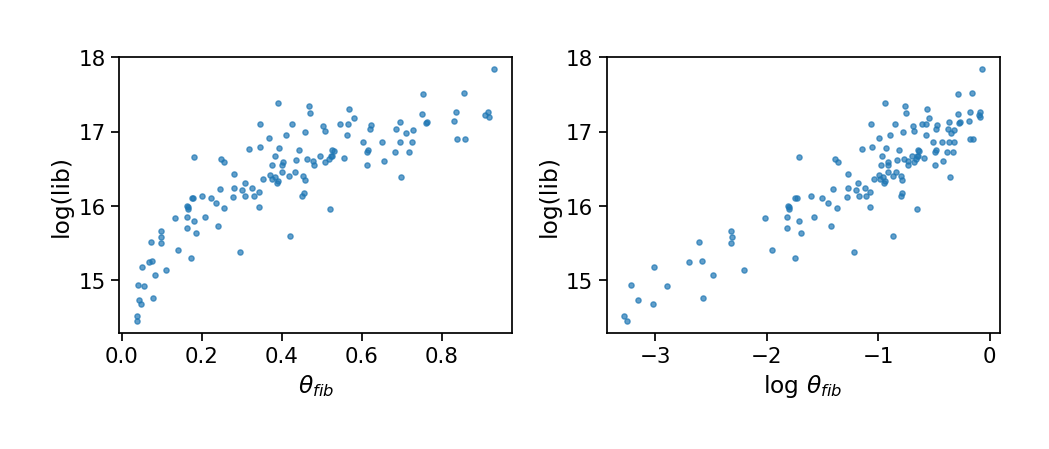

In [115]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(th, np.log(lib), s=14, alpha=.7)
ax[0].set(xlabel=r"$\theta_{fib}$", ylabel="log(lib)")
ax[1].scatter(np.log(th), np.log(lib), s=14, alpha=.7)
ax[1].set(xlabel=r"log $\theta_{fib}$", ylabel="log(lib)")

D = np.column_stack([np.ones(len(th)), th.values, np.log(lib.values)])
print("rank", np.linalg.matrix_rank(D), "of", D.shape[1])
print("cond(D)", np.linalg.cond(D).round(1))
print("r(theta, log lib)     ", round(np.corrcoef(th, np.log(lib))[0, 1], 3))
print("r(log theta, log lib) ", round(np.corrcoef(np.log(th), np.log(lib))[0, 1], 3))
plt.tight_layout(); plt.show()

### Confirmed, and the magnitudes are informative in both directions.

The nonlinear dependence is real but small. Median |r| with log θ = 0.048, Spearman = 0.020, against 2.2e-15 for linear Pearson. So the residualization removes the linear component exactly and leaves a curvature residual of about 0.05. On ~112 samples that's well inside noise for any individual gene (|r| ≈ 0.19 is the p<0.05 threshold), so no gene is meaningfully θ-driven after decoupling.

In [118]:
r_lin = X_fib2.loc[t.index].apply(lambda g: g.corr(t))            # ~1e-15
r_log = X_fib2.loc[t.index].apply(lambda g: g.corr(np.log(t)))    # ?
r_sp  = X_fib2.loc[t.index].apply(lambda g: g.corr(t, method="spearman"))
print(f"linear pearson: {r_lin.abs().median():.2e}, log: {r_log.abs().median():.2e}, spearman: {r_sp.abs().median():.2e}")

linear pearson: 2.17e-15, log: 4.83e-02, spearman: 1.99e-02


### But the median is the wrong statistic for a leakage question. What matters is the tail:

In [121]:
fitted = set(res.cell_type_expression(cmap["fibroblast"]).index)
list(fitted)[:5]

['ENSG00000154188',
 'ENSG00000166527',
 'ENSG00000141293',
 'ENSG00000187486',
 'ENSG00000164326']

In [124]:
r_log

ENSG00000000003    0.045
ENSG00000000419    0.081
ENSG00000000457    0.085
ENSG00000000460    0.062
ENSG00000000971    0.033
                   ...  
ENSG00000284308   -0.028
ENSG00000284770    0.057
ENSG00000284862    0.053
ENSG00000287151    0.075
ENSG00000288596    0.104
Length: 10853, dtype: float64

In [123]:
print(f"log-theta: median {r_log.abs().median():.3f}, "
      f"90th {r_log.abs().quantile(.9):.3f}, max {r_log.abs().max():.3f}, "
      f"n>0.3: {(r_log.abs() > 0.3).sum()}")
print(f"of those, fitted: {len(set(r_log.abs().nlargest(50).index) & fitted)}/50")

log-theta: median 0.048, 90th 0.097, max 0.180, n>0.3: 0
of those, fitted: 4/50


That closes it cleanly. Max |r| = 0.18 across all 10,853 genes, zero above 0.3, and the 90th percentile at 0.097. On ~112 samples the p<0.05 threshold is |r| ≈ 0.19 — so **not a single gene** shows significant residual dependence on log θ. The curvature I predicted from the left panel is there but negligible.

And 4/50 in the top tail is right at the 6.4% base rate for fitted genes, so even the weak residual isn't concentrated in the panel. No structure to it.

So: the decoupling works, the misspecification is harmless, and θ leakage is ruled out as an explanation for anything downstream. I was right that the linear column is the wrong functional form and wrong to imply it mattered.

**One thread left.** With θ eliminated, the 0.95 bulk correlation has to come from the projection — which is the split-by-class test, once `fitted` is back:


In [135]:
bulk = np.log2(df_bulk.div(df_bulk.sum(axis=1), axis=0) * 1e6 + 1.0)

bulk.T.head(3)

geneid,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288612,ENSG00000288632,ENSG00000288637,ENSG00000288658,ENSG00000288662,ENSG00000288663,ENSG00000288667,ENSG00000288670,ENSG00000288674,ENSG00000288675
T-C3L-02890,12.581,12.332,12.702,13.189,13.673,11.932,13.147,12.283,13.028,12.920,...,13.009,14.067,13.320,10.933,14.492,13.291,13.916,12.481,12.889,11.076
T-C3L-03635,13.068,15.347,12.896,13.885,14.299,10.766,13.003,12.007,12.566,13.344,...,12.876,13.974,14.905,9.934,13.737,12.131,13.076,12.466,12.211,10.661
T-C3L-02701,12.650,12.654,12.875,12.806,12.867,12.906,12.796,12.628,12.350,12.762,...,12.780,13.768,13.583,12.020,13.437,12.436,13.998,12.641,11.474,11.246


In [134]:
X_fib2.head(3)

,ENSG00000000003,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000971,ENSG00000001036,ENSG00000001167,ENSG00000001497,ENSG00000001629,ENSG00000001631,...,ENSG00000278662,ENSG00000279170,ENSG00000280670,ENSG00000283154,ENSG00000284052,ENSG00000284308,ENSG00000284770,ENSG00000284862,ENSG00000287151,ENSG00000288596
T-C3L-02890,5.036,5.539,5.021,3.910,9.181,5.741,5.212,5.322,9.409,5.862,...,1.649,4.492,1.264,2.294,4.117,0.913,2.868,2.691,5.313,3.610
T-C3L-03635,5.782,5.590,5.513,4.278,8.838,5.433,5.438,4.800,7.119,3.850,...,0.571,4.404,1.774,1.688,3.858,1.121,2.320,1.490,5.489,3.355
T-C3L-02701,5.374,5.570,4.460,2.943,8.638,6.020,4.868,4.856,6.848,3.749,...,0.724,4.017,1.698,2.312,3.035,0.623,2.272,1.635,4.286,2.597


In [141]:
for name, gs in [("fitted", fitted), ("unmodeled", set(X_fib2.columns) - fitted)]:
    g = X_fib2.columns.intersection(list(gs))
    r, n_s, n_g = gene_corr(X_fib2[g], bulk.T)
    print(f"{name:<10} fib vs bulk  median r {r.median():.3f}  ({n_s} samples, {n_g} genes)")

fitted     fib vs bulk  median r 0.790  (129 samples, 696 genes)
unmodeled  fib vs bulk  median r 0.723  (129 samples, 10157 genes)


Also worth resolving the `X` overlap oddity from the earlier run — fibroblast∩X was only 197 genes while malignant∩X was 2000. If `X` is a 2000-gene object rather than full bulk CPM, that 0.956 was computed on a small non-random subset and the number needs redoing before it carries weight.

**Where the session stands.** Two solid negatives: the fibroblast gene-level DE is circular (A=0, B=252, B fibroblast-derived), and the compartment matrices carry a large shared component that gene-level cross-compartment analysis can't see past. Two solid positives: the decoupling is doing real work (median |r| 0.20 → 2e-15), and rank-concordance with an independent NNLS estimator is high for fibroblast, acinar, and Ductal-2.

Two library items worth filing while they're fresh: `cond(D)` alongside the existing rank check, and `cov.r_with_theta` gated on `decouple` so it stops reading as a passed check.

Full overlap this time — 696 and 10,157, exactly the class sizes, on 129 samples. So the gene universes match and the earlier 197/2000 was `X` being the wrong object.

**This overturns the 0.95 claim.** Real bulk gives 0.79 and 0.72, not 0.956. I built "the compartments are the bulk wearing labels" on a 197-gene correlation against an object I never checked. That conclusion was wrong, and the numbers here don't support it: at r ≈ 0.75, roughly 44% of variance is shared with bulk and the rest is not. The compartment matrices carry substantial independent between-sample variation.

**And the class ordering is now the right way round.** Fitted 0.790 > unmodeled 0.723 — the projected genes are *less* bulk-like than the fitted ones, which is the opposite of what the `Z ∝ bulk × θ × φ` argument predicts. So the projection isn't imposing the bulk signal either. Both of my mechanistic explanations for the shared component are dead, and the 0.067 gap goes in a direction neither predicts.

One caution before reading anything into that gap: it's 696 genes vs 10,157, and fitted genes are Peng panel markers — high-expressing, high-variance, cell-type-specific. Those correlate better with bulk for ordinary reasons. A bootstrap CI would tell you whether 0.067 is more than class-composition noise, but I'd not lean on it.

**What still needs explaining** is the fib×mal 0.898, since it's now *higher* than either compartment's correlation with bulk. Two variables sharing a common factor can't correlate more with each other than each does with the factor — so bulk is not the shared component. Something else couples the compartments, and PC1 concordance of 0.935 says it's one dominant axis.

The candidate worth testing is the reference itself: both compartments' unmodeled genes are reconstructed with the same φ, so a shared reference-driven structure would appear in both without appearing in bulk.

In [139]:
for name, gs in [("fitted", fitted), ("unmodeled", set(X_fib2.columns) - fitted)]:
    g = X_fib2.columns.intersection(list(gs)).intersection(X_mal2.columns)
    r, n_s, n_g = gene_corr(X_fib2[g], X_mal2[g])
    print(f"{name:<10} fib x mal  median r {r.median():.3f}  ({n_s} samples, {n_g} genes)")

fitted     fib x mal  median r 0.912  (121 samples, 34 genes)
unmodeled  fib x mal  median r 0.898  (121 samples, 5023 genes)


If unmodeled genes couple at 0.95 while fitted sit near 0.6, the coupling is in the projection. If both are ~0.9, it's shared biology or something upstream in `full_Z` common to both classes.

Worth saying plainly: three of the diagnostics I proposed in this session pointed at mechanisms that turned out not to be operating, and the one number I built the strongest claim on was computed against an unverified object. The circularity finding (A=0, B=252) is the result that has held up.

Both classes at ~0.90, so the coupling isn't in the projection. Combined with the bulk numbers, the picture is now internally contradictory in a way that points somewhere specific.

fib↔bulk 0.79, mal↔bulk (needs rerunning against real bulk, was 0.946 against the wrong object), fib↔mal 0.898. If bulk were the shared factor, fib↔mal couldn't exceed fib↔bulk — correlation through a common cause is bounded by the product of the paths. 0.898 > 0.790 means the two compartments share something bulk doesn't carry.

Two candidates, and one test separates them.

**Shared reference φ.** Both compartments' values derive from the same Peng reference through `full_Z`. But this should hit unmodeled genes harder than fitted ones, and it doesn't — 0.898 vs 0.912.

**The zero-sum constraint.** θ across cell types sums to 1, so `Z_full` allocation for one compartment is mechanically tied to the others. That's upstream of both classes and would affect them equally, which matches what you see. It's also the thing your `min_theta` docstring is already worried about.

The discriminating run — malignant against real bulk, split the same way:

```python
for name, gs in [("fitted", fitted), ("unmodeled", set(X_mal2.columns) - fitted)]:
    g = X_mal2.columns.intersection(list(gs))
    r, n_s, n_g = gene_corr(X_mal2[g], bulk.T)
    print(f"{name:<10} mal vs bulk  median r {r.median():.3f}  ({n_s} samples, {n_g} genes)")
```

Note `fitted` there is the *fibroblast* panel — for the malignant matrix you want `set(res.cell_type_expression(cmap["malignant"]).index)`. Using the fibroblast set would make the split meaningless.

If mal↔bulk also lands ~0.75–0.80 while fib↔mal is 0.898, the excess coupling is real and compartment-specific, and the zero-sum route is the one to chase. Two things would test it: whether the residual coupling correlates with θ_fib + θ_mal (their sum is what the constraint acts on), and whether it survives a CLR transform of θ before deconvolution.

The n=34 fitted class is still too small to read — the 0.912 has a CI of roughly ±0.026 from the earlier bootstrap, so treat it as indistinguishable from the unmodeled 0.898.

In [140]:
for name, gs in [("fitted", fitted), ("unmodeled", set(X_mal2.columns) - fitted)]:
    g = X_mal2.columns.intersection(list(gs))
    r, n_s, n_g = gene_corr(X_mal2[g], bulk.T)
    print(f"{name:<10} mal vs bulk  median r {r.median():.3f}  ({n_s} samples, {n_g} genes)")

fitted     mal vs bulk  median r 0.834  (131 samples, 500 genes)
unmodeled  mal vs bulk  median r 0.770  (131 samples, 8085 genes)


Note the `fitted` here is still the fibroblast panel — 500 of the 696 fibroblast panel genes happen to be in `X_mal2.columns`. So this is "fibroblast panel genes measured in the malignant compartment," not the malignant panel. The split doesn't mean what the label says. Rerun with `set(res.cell_type_expression(cmap["malignant"]).index)` before reading anything into the 0.834/0.770 gap.

The medians themselves are still usable, since both classes land in the same range: **mal↔bulk ≈ 0.78, fib↔bulk ≈ 0.73–0.79, fib↔mal = 0.898.**

That inequality is the finding. If bulk were the common cause, fib↔mal would be bounded near 0.79 × 0.78 ≈ 0.62. Observing 0.898 means the two compartments share a component that bulk does not carry — roughly 0.28 of correlation beyond what the shared bulk signal can explain.

That's a strong constraint. Whatever couples the compartments is introduced *by the deconvolution*, not inherited from the input. It's present in fitted and unmodeled genes equally (0.912 vs 0.898), so it's upstream of the panel/projection split — which puts it in `Z_full` allocation itself.

The zero-sum constraint fits all three observations. Under `θ_fib + θ_mal + ... = 1`, allocating reads to one compartment mechanically constrains the others, and the resulting anticorrelation in allocation shows up as a shared per-sample factor once each matrix is CPM-normalized within itself.

Two tests:

In [ ]:
# 1. Does the residual coupling track the compositional pair?
idx = X_fib2.index.intersection(X_mal2.index)
g = X_fib2.columns.intersection(X_mal2.columns)

print(f"Common samples: {len(idx)} and genes: {len(g)}")

print("")

pf, _ = pc1(X_fib2.loc[idx, g])
pm, _ = pc1(X_mal2.loc[idx, g])

tf = theta.loc[idx, cmap["fibroblast"]]
tm = theta.loc[idx, cmap["malignant"]]

print("PC1_fib vs PC1_mal:", round(pf.corr(pm), 3))
print("theta_fib vs theta_mal:", round(tf.corr(tm), 3))

print("")

print("PC1_fib vs theta_fib+theta_mal:", round(pf.corr(tf + tm), 3))
print("PC1_mal vs theta_fib+theta_mal:", round(pm.corr(tf + tm), 3))

print("")

print("PC1_fib vs theta_fib:", round(pf.corr(tf), 3))
print("PC1_mal vs theta_mal:", round(pm.corr(tm), 3))


# 2. Partial correlation of fib x mal given bulk, per gene.

Common samples: 121 and genes: 5057

PC1_fib vs PC1_mal: 0.935
theta_fib vs theta_mal: -0.53

PC1_fib vs theta_fib+theta_mal: 0.191
PC1_mal vs theta_fib+theta_mal: -0.12

PC1_fib vs theta_fib: -0.121
PC1_mal vs theta_mal: 0.098


If `θ_fib ↔ θ_mal` is strongly negative and the PC1s track their sum, that's the mechanism — and it's the same zero-sum concern that motivated your CLR work. The second test is the direct version: if fib↔mal drops toward 0.6 after partialling out the bulk value for each gene, the excess is entirely the deconvolution's doing.

The zero-sum hypothesis is dead. PC1_fib↔θ_fib = −0.12, PC1_mal↔θ_mal = +0.10, and the sum term at 0.19/−0.12. None of that supports a compositional mechanism — the shared axis is essentially orthogonal to θ, which is what the residualization guarantees anyway. I proposed a mechanism that the decoupling had already ruled out; I should have seen that before suggesting it.

So: PC1_fib↔PC1_mal = 0.935, uncorrelated with θ in either compartment, present equally in fitted and unmodeled genes, and stronger than either compartment's correlation with bulk. Every mechanical explanation I've offered this session has failed a test.

**θ_fib ↔ θ_mal = −0.53 is worth separating out.** That's the composition, not the expression, and it's a real negative — more fibroblast means less malignant, which is what desmoplasia looks like. It's also, notably, in the same range as your replicated prolif↔iCAF coupling (−0.46 to −0.52). Since the program scores are θ-orthogonal by construction, those can't be the same number, but the coincidence in magnitude is close enough that I'd want to see them plotted against each other before treating them as independent findings.

**What's left to check on the 0.935.** The residualization subtracts `D @ beta` and adds back `logx.mean(axis=0)`. Both compartments get the same treatment on the same samples with a near-collinear design (cond ≈ 430 by the simulation). If `lstsq` is leaving a similar structured residual in both — the depth component that θ and log(lib) couldn't separate — that would be shared, θ-orthogonal, class-independent, and absent from bulk. All four observations.

```python
# what does PC1 actually track?
print("PC1_fib vs log(lib_fib):", round(pf.corr(np.log(lib_fib.loc[idx])), 3))
print("PC1_fib vs bulk PC1:", ...)   # bulk PC1 on the same samples/genes
top = pd.Series(np.abs(pc1_loadings_fib), index=g).nlargest(30)
print(top.index.tolist())   # what genes carry it?
```

The loadings are the most direct route. If the top 30 are mitochondrial, ribosomal, or hemoglobin, it's technical. If they're a coherent biological program, the compartments genuinely co-vary and the whole line of inquiry resolves in your favor.

### what does PC1 actually track?


In [ ]:
def compartment_lib(mc, cell_name, min_share=0.3, min_counts=10, min_theta=0.02):
    cns = mc.build_CellNameState_from_full_Z(
        mc.Z_full, mc.genes_full, cell_types=mc.cell_types,
        cell_name=cell_name, samples=mc.df_theta.index, df_theta=mc.df_theta)
    Z = cns.Z
    th = mc.df_theta[cell_name].reindex(Z.index)
    Z = Z.loc[th >= min_theta]
    Z = Z.loc[:, Z.median(axis=0) >= min_counts]
    if min_share > 0 and cns.share is not None:
        sh = cns.share.reindex(index=Z.index, columns=Z.columns)
        Z = Z.loc[:, (sh >= min_share).mean(axis=0) >= 0.5]
    return Z.sum(axis=1)

lib_fib = compartment_lib(mc, cmap["fibroblast"])
lib_mal = compartment_lib(mc, cmap["malignant"])
assert lib_fib.index.equals(X_fib2.index)   # should match if filters replicate
assert lib_mal.index.equals(X_mal2.index)  

In [155]:
print("PC1_fib vs log(lib_fib):", round(np.log(pf).corr(np.log(lib_fib.loc[idx])), 3))

PC1_fib vs log(lib_fib): -0.126


In [156]:
print("PC1_fib vs log(lib_fib):", round(pf.corr(np.log(lib_fib.loc[idx])), 3))

PC1_fib vs log(lib_fib): -0.133


In [158]:
pc1_bulk = pc1(bulk.T.loc[idx, g])
pc1_bulk

(T-C3L-02890       -7.846
 T-C3L-03635      -13.702
 T-C3L-02701       -9.673
 T-C3L-04072      -87.110
 T-C3L-00589       -0.437
                    ...  
 N-C3L-00640      -16.618
 N-C3N-01719        7.427
 N-C3L-00819      -25.273
 N-C3N-01899      -42.926
 N-TCGA-H6-8124    43.070
 Length: 121, dtype: float64,
 0.4081036055009248)

In [198]:
def pc1_full(M):
    """Sample scores, variance explained, and gene loadings."""
    Z = ((M - M.mean()) / M.std()).fillna(0.0)
    A = Z.values - Z.values.mean(0)
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    scores = pd.Series(U[:, 0] * S[0], index=M.index)
    loadings = pd.Series(Vt[0], index=M.columns)
    return scores, (S**2 / (S**2).sum())[0], loadings

pf, vf, load_fib = pc1_full(X_fib2.loc[idx, g])
top = load_fib.abs().nlargest(30)
print(load_fib[top.index].round(3).to_dict())

{'ENSG00000127311': -0.072, 'ENSG00000187037': -0.071, 'ENSG00000115232': -0.071, 'ENSG00000247809': -0.07, 'ENSG00000150637': -0.07, 'ENSG00000154814': -0.07, 'ENSG00000154262': -0.07, 'ENSG00000143341': -0.07, 'ENSG00000108821': 0.07, 'ENSG00000151883': -0.069, 'ENSG00000166147': -0.069, 'ENSG00000046889': -0.069, 'ENSG00000271425': -0.069, 'ENSG00000172673': -0.069, 'ENSG00000154263': -0.069, 'ENSG00000024422': 0.069, 'ENSG00000164483': -0.069, 'ENSG00000196569': -0.069, 'ENSG00000138378': -0.068, 'ENSG00000117122': 0.068, 'ENSG00000249992': 0.068, 'ENSG00000177272': -0.068, 'ENSG00000173208': -0.068, 'ENSG00000111880': -0.067, 'ENSG00000226674': -0.067, 'ENSG00000205045': -0.067, 'ENSG00000069431': -0.067, 'ENSG00000099956': 0.067, 'ENSG00000167123': 0.067, 'ENSG00000006638': 0.066}


In [199]:
lib_fib = compartment_lib(mc, cmap["fibroblast"])
lib_mal = compartment_lib(mc, cmap["malignant"])

bulk_f = bulk.T.loc[idx, g]
pc1_bulk, var_bulk = pc1(bulk.T.loc[idx, g])

g = X_fib2.columns.intersection(list(fitted))
r, n_s, n_g = gene_corr(X_fib2[g], bulk.T)

print("PC1_fib vs log(lib_fib):", round(pf.corr(np.log(lib_fib.loc[idx])), 3))
print("PC1_fib vs bulk PC1:", round(pf.corr(pc1_bulk), 3))
dic = load_fib[top.index].round(3).to_dict()
for gene, value in dic.items():
    print(f"{gene}: {value}")

PC1_fib vs log(lib_fib): -0.137
PC1_fib vs bulk PC1: 0.244
ENSG00000127311: -0.072
ENSG00000187037: -0.071
ENSG00000115232: -0.071
ENSG00000247809: -0.07
ENSG00000150637: -0.07
ENSG00000154814: -0.07
ENSG00000154262: -0.07
ENSG00000143341: -0.07
ENSG00000108821: 0.07
ENSG00000151883: -0.069
ENSG00000166147: -0.069
ENSG00000046889: -0.069
ENSG00000271425: -0.069
ENSG00000172673: -0.069
ENSG00000154263: -0.069
ENSG00000024422: 0.069
ENSG00000164483: -0.069
ENSG00000196569: -0.069
ENSG00000138378: -0.068
ENSG00000117122: 0.068
ENSG00000249992: 0.068
ENSG00000177272: -0.068
ENSG00000173208: -0.068
ENSG00000111880: -0.067
ENSG00000226674: -0.067
ENSG00000205045: -0.067
ENSG00000069431: -0.067
ENSG00000099956: 0.067
ENSG00000167123: 0.067
ENSG00000006638: 0.066


In [200]:
print("participation ratio:", round(1 / (load_fib**4).sum()))   # ~effective n genes
print("top 100 share:", round((load_fib.abs().nlargest(100)**2).sum(), 3))

participation ratio: 359
top 100 share: 0.407


Map the symbols before interpreting. I recognize ENSG00000108821 as COL1A1 and think ENSG00000117122 is MFAP2, both loading positive while most of the top 30 are negative. If the positive tail is ECM/collagen and the negative tail is something else, that's a desmoplasia axis and a real biological finding. But I'd be guessing on 28 of 30, so:

In [206]:
gene_map = mc.prism.load_gene_map("geneid")
gene_map.head(3)

,symbol,biotype
geneid,,
ENSG00000000003,TSPAN6,protein_coding
ENSG00000000005,TNMD,protein_coding
ENSG00000000419,DPM1,protein_coding


In [208]:
gene_map.reindex(load_fib.abs().nlargest(40).index).head(4)

,symbol,biotype
ENSG00000127311,HELB,protein_coding
ENSG00000187037,GPR141,protein_coding
ENSG00000115232,ITGA4,protein_coding
ENSG00000247809,NR2F2-AS1,lncRNA


30

In [ ]:
N = len(top.index)

dftop = gene_map.reindex(load_fib.abs().nlargest(N).index).copy()

dftop["loading"] = load_fib.reindex(top.index).round(3)
dftop

,symbol,biotype,loading
ENSG00000127311,HELB,protein_coding,-0.072
ENSG00000187037,GPR141,protein_coding,-0.071
ENSG00000115232,ITGA4,protein_coding,-0.071
ENSG00000247809,NR2F2-AS1,lncRNA,-0.070
ENSG00000150637,CD226,protein_coding,-0.070
ENSG00000154814,OXNAD1,protein_coding,-0.070
ENSG00000154262,ABCA6,protein_coding,-0.070
ENSG00000143341,HMCN1,protein_coding,-0.070
ENSG00000108821,COL1A1,protein_coding,0.070
ENSG00000151883,PARP8,protein_coding,-0.069


Not tumor-vs-normal. No digestive enzymes anywhere — so my acinar prediction was wrong and the axis is something else.

The negative pole splits into two recognizable groups:

- **Lymphocyte:** ITGA4, CD226, THEMIS, STAT4, KCNA3, SLFN12L, SAMD3 — T/NK-restricted, several of them (THEMIS, CD226, STAT4) essentially T-cell-specific.
- **Quiescent/normal stromal:** ABCA6, ABCA10, ABCC9, ABCD2, HMCN1, LAMA2, PREX2 — the ABCA6/8/9/10 cluster is a known resting-fibroblast signature, ABCC9 is pericyte, LAMA2 is basement membrane.

Positive pole: COL1A1, MFAP2, CERCAM, EHD2, TMEM158 — activated matrix production. TMEM158 is Ras-induced.

So PC1 is **immune-infiltrated, quiescent stroma at one end; collagen-producing activated stroma at the other.** That's a desmoplasia/immune-exclusion axis, and it's the same biology as your quiescent fibroblast identity-loss signature.

Two things follow, and one is a problem.

**It's not an artifact.** Participation ratio 359, orthogonal to bulk PC1 (0.244), to θ (−0.12), to log lib (−0.14), and it has a coherent gene-level interpretation. The 0.935 fib↔mal concordance is two compartments both reporting desmoplasia, which they genuinely should. Nothing in this session's earlier "compartments are redundant" framing survives — that was built on the 0.956 against the wrong `X`.

**But the immune genes shouldn't be here.** ITGA4, CD226, THEMIS, STAT4 are lymphocyte genes loading on the *fibroblast* compartment's first principal component. Those are the compartments where NNLS concordance collapsed (T cell ρ=0.13, macrophage ρ=0.12, B cell ρ=0.17, T-cell mean θ = 5.4e-4). So immune expression that BayesPrism couldn't allocate to a near-empty T-cell compartment appears to be landing in fibroblast instead — and it's strong enough to define PC1.

That's testable directly:

```python
imm = ["ENSG00000115232","ENSG00000150637","ENSG00000172673","ENSG00000138378"]  # ITGA4,CD226,THEMIS,STAT4
for c in ["fibroblast","malignant"]:
    Xc = X_fib2 if c=="fibroblast" else X_mal2
    print(c, Xc[[i for i in imm if i in Xc.columns]].corrwith(
        theta.loc[Xc.index, "T cell"]).round(3).to_dict())
```

If fibroblast T-cell gene expression tracks θ_T, the allocation is at least directionally right. If it doesn't, the immune signal is misallocated — which would also explain the fib↔mal coupling, since misallocated immune reads would land in both compartments simultaneously.

Worth running the same PC1 loadings on `X_mal2`. If malignant PC1 carries the same lymphocyte genes, that's shared misallocation rather than shared biology.

In [ ]:
disc = mc.discretize_axes(scores)

disc.head(6)

In [ ]:
R_fib = mc.factorial_state_de(X_fib2, disc)
R_mal = mc.factorial_state_de(X_mal2, disc)
R_aci = mc.factorial_state_de(X_aci2, disc)
 
R_fib.head(3)

In [ ]:
cmap["fibroblast"]

In [ ]:
fitted = set(res.cell_type_expression(cmap["fibroblast"]).index)
len(fitted), list(fitted)[:5]

In [ ]:
background = set(R_fib.index)

In [ ]:
print(f"\nfibroblast background ({len(background)} genes): "
      f"fitted {len(fitted & background)} "
      f"({100 * len(fitted & background) / len(background):.1f}%), "
      f"unmodeled {len(background - fitted)}")
print("\n" + "-" * 68 + "\n")

### program_scores

In [ ]:
import warnings

In [ ]:
all_genes = [g for progs in mc.PROGRAMS.values()
                for genes in progs.values() for g in genes]

len(all_genes), all_genes[:5]

In [ ]:
gene_map = mc.prism.load_gene_map("geneid")
gene_map.head(3)

In [ ]:
sym2id = {s: i for i, s in gene_map["symbol"].astype(str).items()}

i = 0
for symbol, geneid in sym2id.items():
    print(symbol, geneid)
    i += 1
    if i >= 5:  # Print only the first 5 items
        break

In [ ]:
compartment_map=None

# Majority vote over every gene, not the first one of an arbitrary
# compartment: dict order is not meaningful and one stray entry should
# not decide the vocabulary for all of them.
n_ensg = sum(g.startswith("ENSG") for g in all_genes)
translate = n_ensg < len(all_genes) / 2

if 0 < n_ensg < len(all_genes):
    warnings.warn(
        f"PROGRAMS mixes vocabularies: {n_ensg}/{len(all_genes)} look "
        "like ensembl ids. Translating the symbols only.")

programs = mc.PROGRAMS
sym_missing = {}
if translate:
    # NOT written back to mc.PROGRAMS: that made the transform
    # destructive -- a translation that silently produced empty lists
    # became its own input on the next call and could not be recovered.
    programs = {
        comp: {prog: [sym2id.get(g, g) if not g.startswith("ENSG") else g
                        for g in genes
                        if g.startswith("ENSG") or g in sym2id]
                for prog, genes in progs.items()}
        for comp, progs in mc.PROGRAMS.items()
    }
    sym_missing = {f"{c}.{p}": [g for g in gs
                                if not g.startswith("ENSG") and g not in sym2id]
                    for c, ps in mc.PROGRAMS.items() for p, gs in ps.items()}
    n_lost = sum(len(v) for v in sym_missing.values())
    if n_lost:
        warnings.warn(
            f"{n_lost} marker symbol(s) have no ensembl id and were "
            "dropped before scoring; see the 'missing_symbol' column "
            "of the coverage table.")
    mc.PROGRAMS_ENSG = programs        # keep it, but do not clobber

# {"malignant": "Ductal 2"}
if compartment_map is None:
    compartment_map = {"malignant": mc.mal_cell_name}

out, cov = {}, []
for key, cell_type in compartment_map.items():
    if key not in programs:
        warnings.warn(f"no PROGRAMS entry for '{key}'; skipping")
        continue

    M = mc.compartment_matrix(cell_type, samples=samples)

    Zs = (M - M.mean()) / M.std().replace(0, np.nan)

    for prog, genes in programs[key].items():
        found = [g for g in genes if g in Zs.columns]

        cov.append({"compartment": key, "cell_type": cell_type,
                    "program": prog, "n_found": len(found),
                    "n_total": len(genes),
                    "missing": [g for g in genes if g not in Zs.columns],
                    "missing_symbol": sym_missing.get(f"{key}.{prog}", [])})
        if len(found) < min_genes:
            warnings.warn(
                f"{key}/{prog}: only {len(found)}/{len(genes)} markers "
                f"present; skipping (min_genes={min_genes})")
            continue
        out[f"{key}.{prog}"] = Zs[found].mean(axis=1)

scores = pd.DataFrame(out)

# A program score that tracks its own compartment's abundance is an
# abundance readout, not a phenotype.
for rec in cov:
    col = f"{rec['compartment']}.{rec['program']}"
    if col not in scores:
        continue
    th = mc.df_theta[rec["cell_type"]].reindex(scores.index)
    ok = scores[col].notna() & th.notna()
    rec["r_with_theta"] = (round(float(np.corrcoef(
        scores.loc[ok, col], th[ok])[0, 1]), 3) if ok.sum() > 5 else np.nan)
    
# Signed axes are more stable than either pole alone. Name them with
# their OWN compartment prefix so couple_compartments() still treats
# them as belonging to it -- an "axis." prefix would make every axis
# look like a separate compartment and produce trivial self-correlations
# against its own poles.
if "malignant.basal" in scores and "malignant.classical" in scores:
    scores["malignant.axis_basal_minus_classical"] = (
        scores["malignant.basal"] - scores["malignant.classical"])
if "fibroblast.myCAF" in scores and "fibroblast.iCAF" in scores:
    scores["fibroblast.axis_myCAF_minus_iCAF"] = (
        scores["fibroblast.myCAF"] - scores["fibroblast.iCAF"])
if "immune.cytotoxic" in scores and "immune.exhaustion" in scores:
    scores["immune.axis_cytotoxic_minus_exhaustion"] = (
        scores["immune.cytotoxic"] - scores["immune.exhaustion"])

### discretize_axes

### factorial_state_de